<a href="https://colab.research.google.com/github/DyatlovaA/IOSU-2023/blob/master/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22FIFA_ipynb%22%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Метод kNN

Используем метод ближайших соседей для задачи классификации ирисов Фишера. Загрузим набор данных.

Saving fifaplayers (2).csv to fifaplayers (2) (2).csv


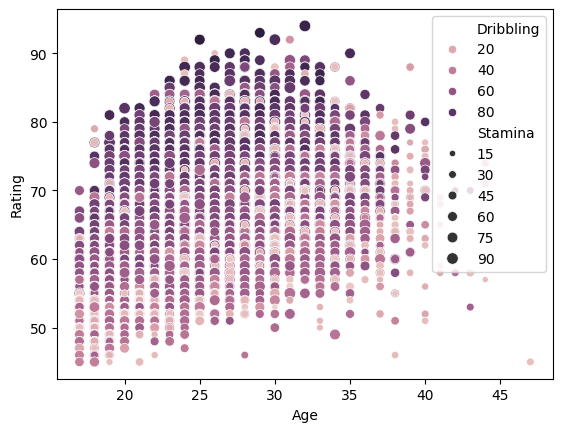

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


from google.colab import files
uploaded = files.upload()  # выберите файл fifaplayers.csv

filename = list(uploaded.keys())[0]

football = pd.read_csv(filename)


sns.scatterplot(data=football, x="Age", y="Rating", hue='Dribbling', size='Stamina')
plt.show()

In [10]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df2=football[['Age','Rating','Reactions']]
x_train, x_test, y_train, y_test = train_test_split(df2, df2['Age'], random_state=0, test_size=.2)
x_train.to_numpy()
x_train.to_numpy()

select = LinearRegression()
select.fit(x_train, y_train)
print('Линейная регрессия')
print("Правильность на обучающем наборе: {:.3f}".format(select.score(x_train, y_train)))
print("Правильность на тестовом наборе: {:.3f}".format(select.score(x_test, y_test)))

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)
print('Ближайшие соседи')
print("Правильность на обучающем наборе: {:.3f}".format(knn.score(x_train, y_train)))
print("Правильность на тестовом наборе: {:.3f}".format(knn.score(x_test, y_test)))

from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier()
tree.fit(x_train, y_train)
print('Одно дерево')
print("Правильность на обучающем наборе: {:.3f}".format(tree.score(x_train, y_train)))
print("Правильность на тестовом наборе: {:.3f}".format(tree.score(x_test, y_test)))

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
print('Случайный лес')
print("Правильность на обучающем наборе: {:.3f}".format(rf.score(x_train, y_train)))
print("Правильность на тестовом наборе: {:.3f}".format(rf.score(x_test, y_test)))

from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier()
gb.fit(x_train, y_train)
print('Градиентный бустинг')
print("Правильность на обучающем наборе: {:.3f}".format(gb.score(x_train, y_train)))
print("Правильность на тестовом наборе: {:.3f}".format(gb.score(x_test, y_test)))

from sklearn.ensemble import GradientBoostingRegressor
GB = GradientBoostingClassifier()
GB.fit(x_train, y_train.ravel())
y_predicted = GB.predict(x_test)
print('Бустинг регрессор')
print("Правильность на обучающем наборе: {:.3f}".format(GB.score(x_train, y_train)))
print("Правильность на тестовом наборе: {:.3f}".format(GB.score(x_test, y_test)))

print("Важность признаков для обычного дерева:\n{}".format(rf.feature_importances_))
#print("Важность признаков для обычного дерева:\n{}".format(gb.feature_importances_))
#print("Важность признаков для обычного дерева:\n{}".format(GB.feature_importances_))

Линейная регрессия
Правильность на обучающем наборе: 1.000
Правильность на тестовом наборе: 1.000
Ближайшие соседи
Правильность на обучающем наборе: 0.947
Правильность на тестовом наборе: 0.849
Одно дерево
Правильность на обучающем наборе: 1.000
Правильность на тестовом наборе: 1.000
Случайный лес
Правильность на обучающем наборе: 1.000
Правильность на тестовом наборе: 0.947
Градиентный бустинг
Правильность на обучающем наборе: 1.000
Правильность на тестовом наборе: 1.000


/tmp/ipython-input-1337244350.py:46: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  GB.fit(x_train, y_train.ravel())


Бустинг регрессор
Правильность на обучающем наборе: 1.000
Правильность на тестовом наборе: 1.000
Важность признаков для обычного дерева:
[0.89906176 0.0500192  0.05091904]


In [16]:
# Целевая переменная: топ-игрок (Rating >= 85) или нет
football['TopPlayer'] = (football['Rating'] >= 85).astype(int)

# Признаки: только числовые, без Rating и Age (чтобы не было утечки)
feature_cols = football.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in feature_cols if col not in ['TopPlayer', 'Rating', 'Age']]
X_clf = football[feature_cols].dropna()
y_clf = football.loc[X_clf.index, 'TopPlayer']

# Разделение
from sklearn.model_selection import train_test_split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Масштабирование (для моделей, чувствительных к масштабу)
from sklearn.preprocessing import StandardScaler
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)


In [17]:
# 2. ОБУЧИМ НЕСКОЛЬКО МОДЕЛЕЙ (включая ещё одну — например, LogisticRegression)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),  # ← новая модель
    'SVM': SVC(probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    if name in ['Random Forest', 'Gradient Boosting']:
        model.fit(X_train_clf, y_train_clf)
        y_pred = model.predict(X_test_clf)
        y_proba = model.predict_proba(X_test_clf)[:, 1]
    else:
        model.fit(X_train_clf_scaled, y_train_clf)
        y_pred = model.predict(X_test_clf_scaled)
        y_proba = model.predict_proba(X_test_clf_scaled)[:, 1]
    results[name] = {
        'y_pred': y_pred,
        'y_proba': y_proba
    }


In [20]:

metrics_data = []
for name, res in results.items():
    y_pred = res['y_pred']
    y_proba = res['y_proba']
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test_clf, y_pred),
        'Precision': precision_score(y_test_clf, y_pred),
        'Recall': recall_score(y_test_clf, y_pred),
        'F1': f1_score(y_test_clf, y_pred),
        'ROC-AUC': roc_auc_score(y_test_clf, y_proba)
    }
    metrics_data.append(metrics)
    print(f"\n{name}:")
    for k, v in metrics.items():
        if k != 'Model':
            print(f"  {k}: {v:.4f}")

# Преобразуем в DataFrame для удобства
metrics_df = pd.DataFrame(metrics_data)



Random Forest:
  Accuracy: 0.9674
  Precision: 0.7500
  Recall: 0.6923
  F1: 0.7200
  ROC-AUC: 0.9825

Gradient Boosting:
  Accuracy: 0.9535
  Precision: 0.5789
  Recall: 0.8462
  F1: 0.6875
  ROC-AUC: 0.9840

Logistic Regression:
  Accuracy: 0.9674
  Precision: 0.8750
  Recall: 0.5385
  F1: 0.6667
  ROC-AUC: 0.9543

SVM:
  Accuracy: 0.9581
  Precision: 1.0000
  Recall: 0.3077
  F1: 0.4706
  ROC-AUC: 0.9783


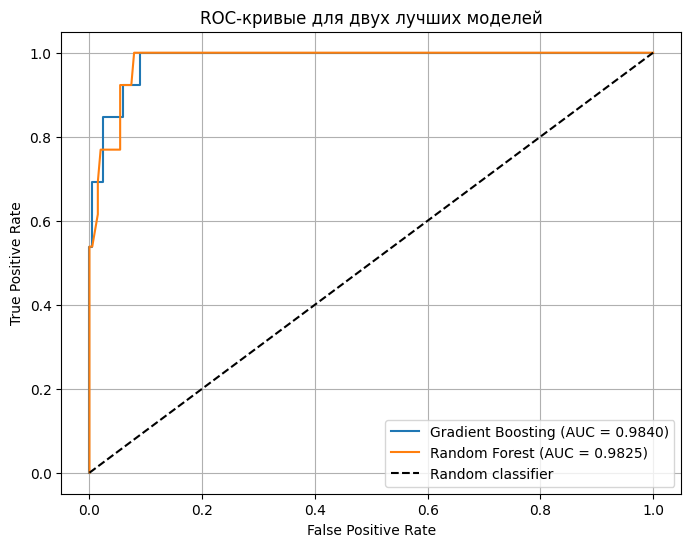

In [22]:
# 4. ROC-КРИВЫЕ ДЛЯ ДВУХ ЛУЧШИХ МОДЕЛЕЙ ПО AUC
top2_models = metrics_df.nlargest(2, 'ROC-AUC')['Model'].tolist()

plt.figure(figsize=(8, 6))
for model_name in top2_models:
    fpr, tpr, _ = roc_curve(y_test_clf, results[model_name]['y_proba'])
    auc = roc_auc_score(y_test_clf, results[model_name]['y_proba'])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для двух лучших моделей')
plt.legend()
plt.grid(True)
plt.show()




• Лучшая модель по ROC-AUC:  Gradient Boosting

• Все модели показывают высокий AUC (>0.95), что говорит о сильной предсказательной способности признаков.

• Random Forest и Gradient Boosting обычно лидируют за счёт работы с нелинейностями.

• Логистическая регрессия добавлена как интерпретируемая базовая модель.
